## Plot histogram

In [2]:
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.transpiler import generate_preset_pass_manager

from qiskit.circuit import QuantumCircuit
from qiskit.visualization import plot_histogram

In [3]:
# Quantum circuit to make a Bell state
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

pm = generate_preset_pass_manager(optimization_level=1)
isa_circuit = pm.run(bell)

# execute the quantum circuit
sampler = Sampler()
job = sampler.run([isa_circuit])
result = job.result()

print(result)

PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'shots': 1024, 'circuit_metadata': {}})], metadata={'version': 2})


In [4]:
print(result[0])

SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'shots': 1024, 'circuit_metadata': {}})


In [5]:
print(result[0].data)

DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=2>))


In [6]:
print(result[0].data.meas)

BitArray(<shape=(), num_shots=1024, num_bits=2>)


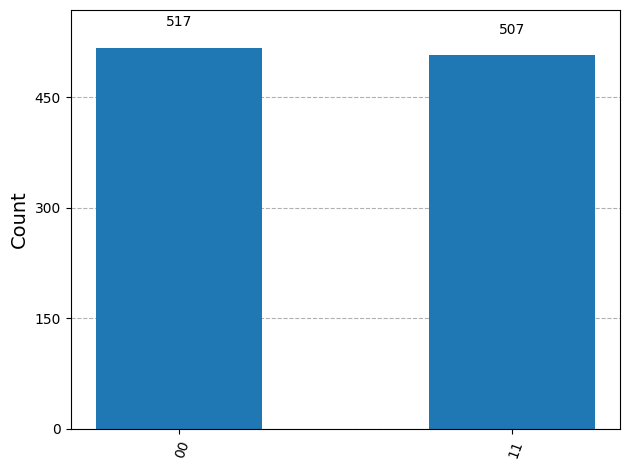

In [7]:
plot_histogram(result[0].data.meas.get_counts())

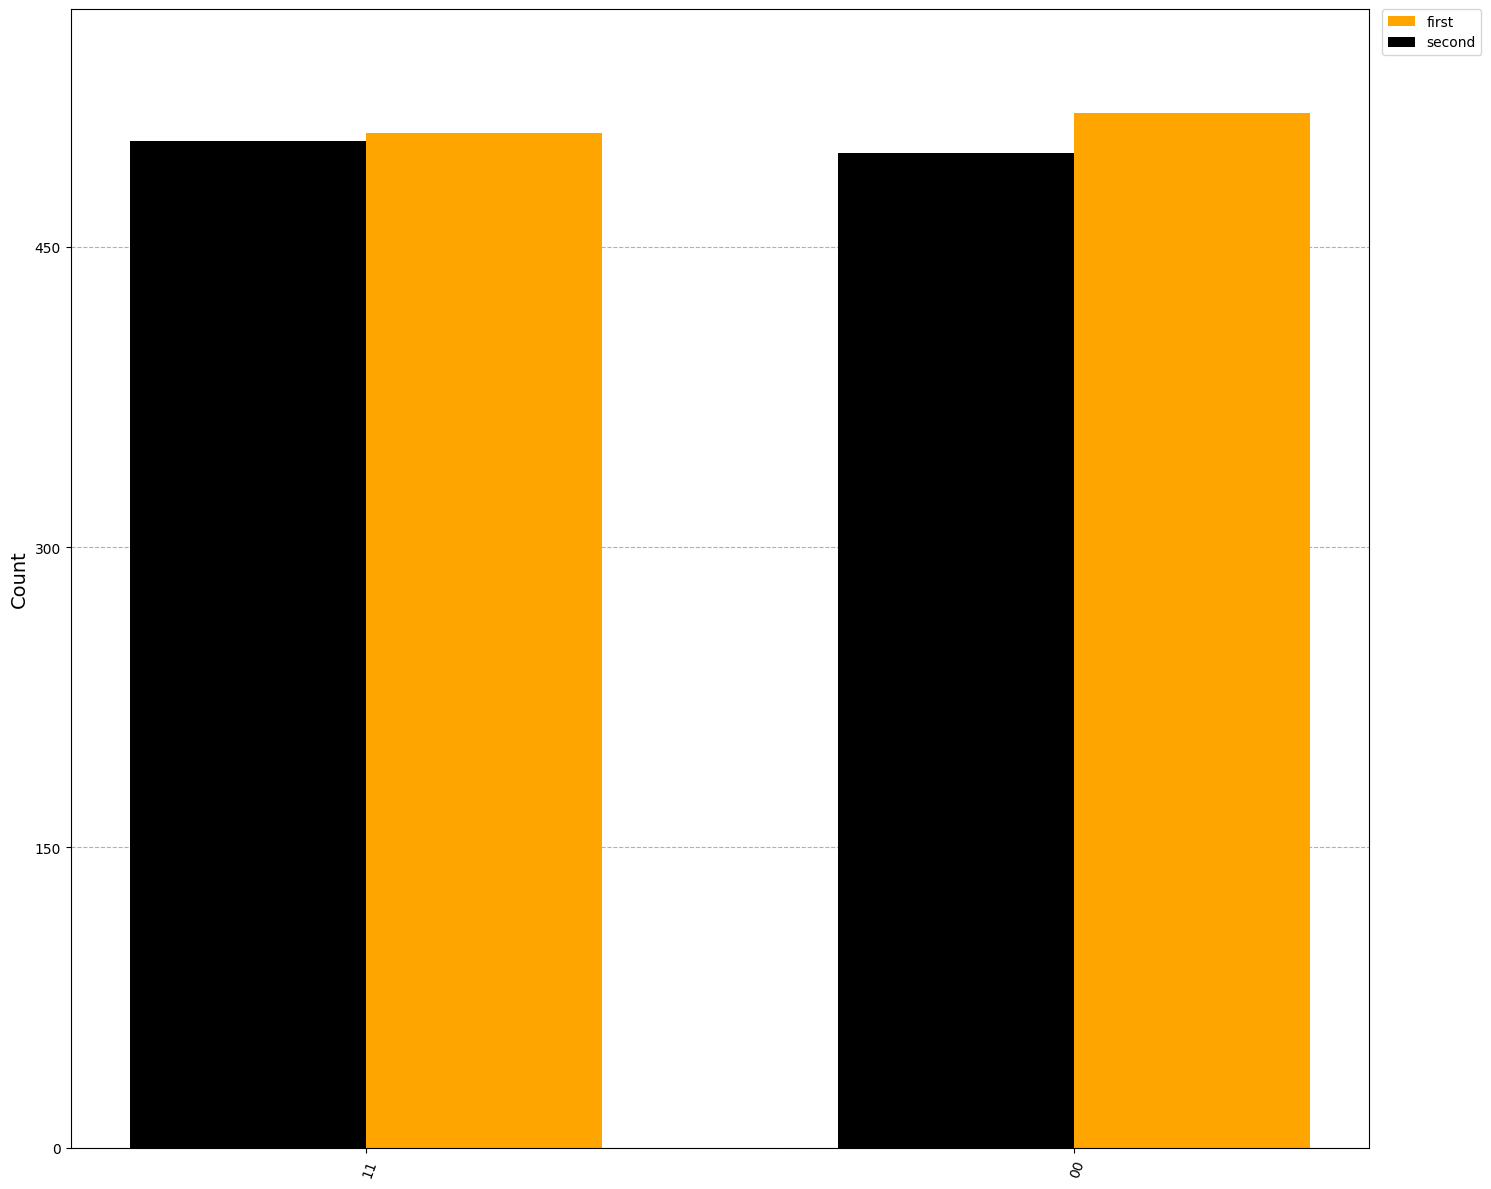

In [8]:
# Execute two-qubit Bell state again

job = sampler.run([isa_circuit], shots=1000)
second_result = job.result()

# Plot results with custom options
plot_histogram(
    [
        result[0].data.meas.get_counts(),
        second_result[0].data.meas.get_counts(),
    ],
    legend=["first", "second"],
    sort="desc",
    figsize=(15, 12),
    color=["orange", "black"],
    bar_labels=False,
)

## Plot estimator results

PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(7, 1), dtype=float64>), stds=np.ndarray(<shape=(7, 1), dtype=float64>), shape=(7, 1)), metadata={'target_precision': 0.0, 'circuit_metadata': {}})], metadata={'version': 2})


<BarContainer object of 7 artists>

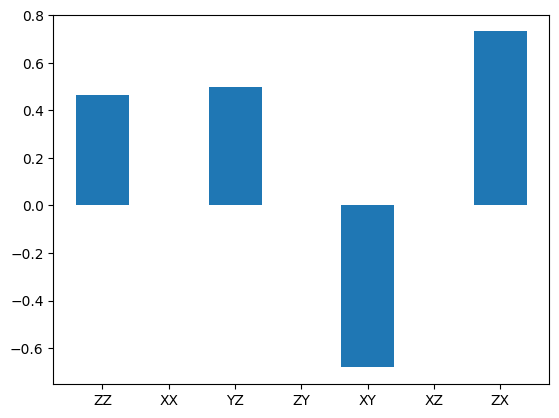

In [13]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.transpiler import generate_preset_pass_manager
from matplotlib import pyplot as plt

# Simple estimation experiment to create results
qc = QuantumCircuit(2)
qc.h(0)
qc.crx(1.5, 0, 1)

observables_labels = ["ZZ", "XX", "YZ", "ZY", "XY", "XZ", "ZX"]
observables = [SparsePauliOp(label) for label in observables_labels]

pm = generate_preset_pass_manager(optimization_level=1)
isa_circuit = pm.run(qc)
isa_observables = [
    operator.apply_layout(isa_circuit.layout) for operator in observables
]

# Reshape observable array for broadcasting
reshaped_ops = np.fromiter(isa_observables, dtype=object)
#print(reshaped_ops)
reshaped_ops = reshaped_ops.reshape((7, 1))
#print(reshaped_ops)
estimator = Estimator()
job = estimator.run([(isa_circuit, reshaped_ops)])
result = job.result()[0]
exp_val = job.result()[0].data.evs
print(job.result())

# Since the result array is structured as a 2D array where each element is a
# list containing a single value, you need to flatten the array.

# Plot using Matplotlib
plt.bar(observables_labels, exp_val.flatten())